In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti
import file_utils as futi
import event_utils as euti


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
# This allow both dict.key and dict['key'] syntax
class AttrDict(dict):
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")

    def __setattr__(self, key, value):
        self[key] = value

    def __delattr__(self, key):
        try:
            del self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")



In [3]:
%%time
nsteps=None
start_date=None
#super_lat_range = [-90.,90.]  #[-85,-30]
super_lat_range = [-80.,-30.]  #[-85,-30]
case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'   , False, [2004,7,15,0], 248
#case, process_ncdata  = 'cam77_dyamond1_prod1'    , False
#case , process_ncdata = 'xy-rdg-mm-front'    , True
A = futi.read_case( case=case, nsteps=nsteps, start_date=start_date , super_lat_range=super_lat_range ) # , nsteps = 31*8 )

time, zlev, lat, lon = A.time, A.zlev, A.lat, A.lon



  nsteps=248 
/glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-15-00000.nc /glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-09-14-64800.nc
 Dataset opened  , dtype of U,V float64 float64 
 Dataset opened  trimmed. -79.63 to -30.63 
X is present 
(248, 93, 53, 288)
(248, 93, 53, 288)
(248, 93, 53, 288)
(248, 93, 53, 288)
this is Sphere_grad_vec in numerical_utils in HiRes_ana
dlat has been adjusted to account for FUCKED UP CRAPPY fv1x1 SCRIP FILE IN CESMDATA INPUTs!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
CPU times: user 51.2 s, sys: 1min 10s, total: 2min 1s
Wall time: 5min 37s


In [4]:
#################################################################
# Make event lists ... and composites
importlib.reload(euti)
importlib.reload(auti)

thresh=0.01 #0.005 # 0.02
thresh=0.001 #0.005 # 0.02
thresh=0.0001 #0.005 # 0.02
zlev_event=10_000. #23_000.
zlev_event=15_000. #23_000.

El=[]

print( f"This run use dycore={A.dycore}")

if A.dycore == 'MPAS':
    ## for MPAS 3km
    thresholds=[  [0.005,1e6], 
                [0.008,1e6],
                [0.01,1e6] ,
                [0.020,1e6]  ] ##[0.025,1e6]  ] ##0.025, ]
    second_thresholds= [
                    [0.005,0.008], 
                    [0.008,0.015],
                    [0.01,0.025] ,
                    [0.020,1e6]  ] ## [0.025,1e6]  ] ##0.025, ]
    big_window=[3,5,5]
    lil_window=[3,2,2]
    
elif A.dycore == 'SE':
    # for ne240
    thresholds=[  [0.0005,1e6], 
                [0.002,1e6],
                [0.005,1e6] ,
                [0.010,1e6]  ] ##[0.025,1e6]  ] ##0.025, ]
    second_thresholds= [
                    [0.0005,0.002], 
                    [0.002,0.0075],
                    [0.005,0.012] ,
                    [0.012,1e6]  ] ## [0.025,1e6]  ] ##0.025, ]
    big_window=[2,5,5]
    lil_window=[2,2,2]

lat_range=  [-65,-40] #[-70,-60] #[-60,-40]
lon_range=[0,60] # [0,60]
lat_range=  [-50,-40] #[-70,-60] #[-60,-40]
lat_range=  [-60,-50] #[-70,-60] #[-60,-40]
lon_range=[0,360] # [0,60]

ithr=0
for thresh in thresholds:
    second_thresh=second_thresholds[ithr]
    ds =euti.make_ds(fld=A.rho_epwp[:,:,:,:], lon=lon, lat=lat, zlev=zlev, time=time, 
                     thresh=thresh,second_thresh=second_thresh,zlev_event=zlev_event, 
                     lat_range=lat_range, lon_range=lon_range)
    ithr=ithr+1
    

    # get shape of varaiables
    nt,nz,ny,nx = np.shape( A.u )
    
    htopo_t = np.tile(A.htopo[None, :, :], ( nt, 1, 1))
    htopo_4D_x , time4D,lat4D,lon4D  = auti.cube4D_ds( event_ds=ds, aa=htopo_t , lon=lon, lat=lat, window=[0,5,5] , TZHkey='tyx', lat_range=[-999,999], lon_range=[-999,999] )
    
    htopo_MMM = auti.collapseSpace( htopo_4D_x , TZHkey='etyx')
    htopo_super_max = htopo_MMM[2].max( axis=1 )
    
    
    ########################################
    # Exclude events with topography nearby
    ########################################
    
    flat=np.where(htopo_super_max<0.0001)
    flat[0].shape
    
    ds_flat=ds.isel( index=flat[0] )    
    ds=ds_flat
    
    E_ = {'ds':ds }

    window=lil_window # [3,2,2]
    #window=[6,2,2] # MPAS results are 3-hourly ...
    if ds.sizes['index'] < 75_000:
        window = big_window #[3,5,5] #[6,5,5]
        print( f"Big window ")
    #window=[6,5,5] # MPAS results are 3-hourly ...
    
    
    
    precl_4D , time4D,lat4D,lon4D  = auti.cube4D_ds( event_ds=ds, aa=A.precl , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    htopo_4D , time4D,lat4D,lon4D  = auti.cube4D_ds( event_ds=ds, aa=htopo_t , lon=lon, lat=lat, window=window , TZHkey='tyx', lat_range=lat_range, lon_range=lon_range )
    zeta_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.zeta , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    tilt_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.tilt , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    fgf_4D, time4D,lat4D,lon4D  = auti.cube4D_ds( event_ds=ds, aa=A.fgf , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    epwp_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.rho_epwp , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    upwp_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.rho_upwp , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    vpwp_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.rho_vpwp , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    u_4D, time4D,lat4D,lon4D    = auti.cube4D_ds( event_ds=ds, aa=A.u , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    v_4D, time4D,lat4D,lon4D    = auti.cube4D_ds( event_ds=ds, aa=A.v , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    th_4D, time4D,lat4D,lon4D   = auti.cube4D_ds( event_ds=ds, aa=A.th , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )

    E_['time4D'], E_['lat4D'], E_['lon4D'] = time4D,lat4D,lon4D
    E_['u_4D'], E_['v_4D'], E_['htopo_4D'] = u_4D,v_4D,htopo_4D
    E_['zeta_4D'], E_['tilt_4D'] , E_['fgf_4D']  = zeta_4D,tilt_4D,fgf_4D
    E_['upwp_4D'], E_['vpwp_4D'] , E_['epwp_4D']  = upwp_4D,vpwp_4D,epwp_4D
    E_['precl_4D'], E_['th_4D'] = precl_4D,th_4D

    E = AttrDict( E_ )
    El.append(E)
    print( f" fininshed threshold = {thresh}. N events: Global= {E.ds.sizes['index']}, Region= {len(time4D)} " )

This run use dycore=SE
Events at Z=14872.906006759258
Length of total event list after time loop  9700 for thresh=[0.0005, 1000000.0]
Big window 
 fininshed threshold = [0.0005, 1000000.0]. N events: Global= 8855, Region= 8855 
Events at Z=14872.906006759258
Length of total event list after time loop  9032 for thresh=[0.002, 1000000.0]
Big window 
 fininshed threshold = [0.002, 1000000.0]. N events: Global= 8160, Region= 8160 
Events at Z=14872.906006759258
Length of total event list after time loop  3828 for thresh=[0.005, 1000000.0]
Big window 
 fininshed threshold = [0.005, 1000000.0]. N events: Global= 3397, Region= 3397 
Events at Z=14872.906006759258
Length of total event list after time loop  1828 for thresh=[0.01, 1000000.0]
Big window 
 fininshed threshold = [0.01, 1000000.0]. N events: Global= 1447, Region= 1447 


In [16]:

print(  np.shape( El[3].zeta_4D ) )


(1447, 3, 93, 11, 11)


[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
 Couldn't average ds over events
 Couldn't average ds over events
 Couldn't average ds over events
 Couldn't average ds over events


"\ncax = fig.add_axes([0.15, -0.1, 0.70, 0.03])\ncbar = fig.colorbar(linc, cax=cax, orientation='horizontal')\ncbar.set_label('Some quantity')\n"

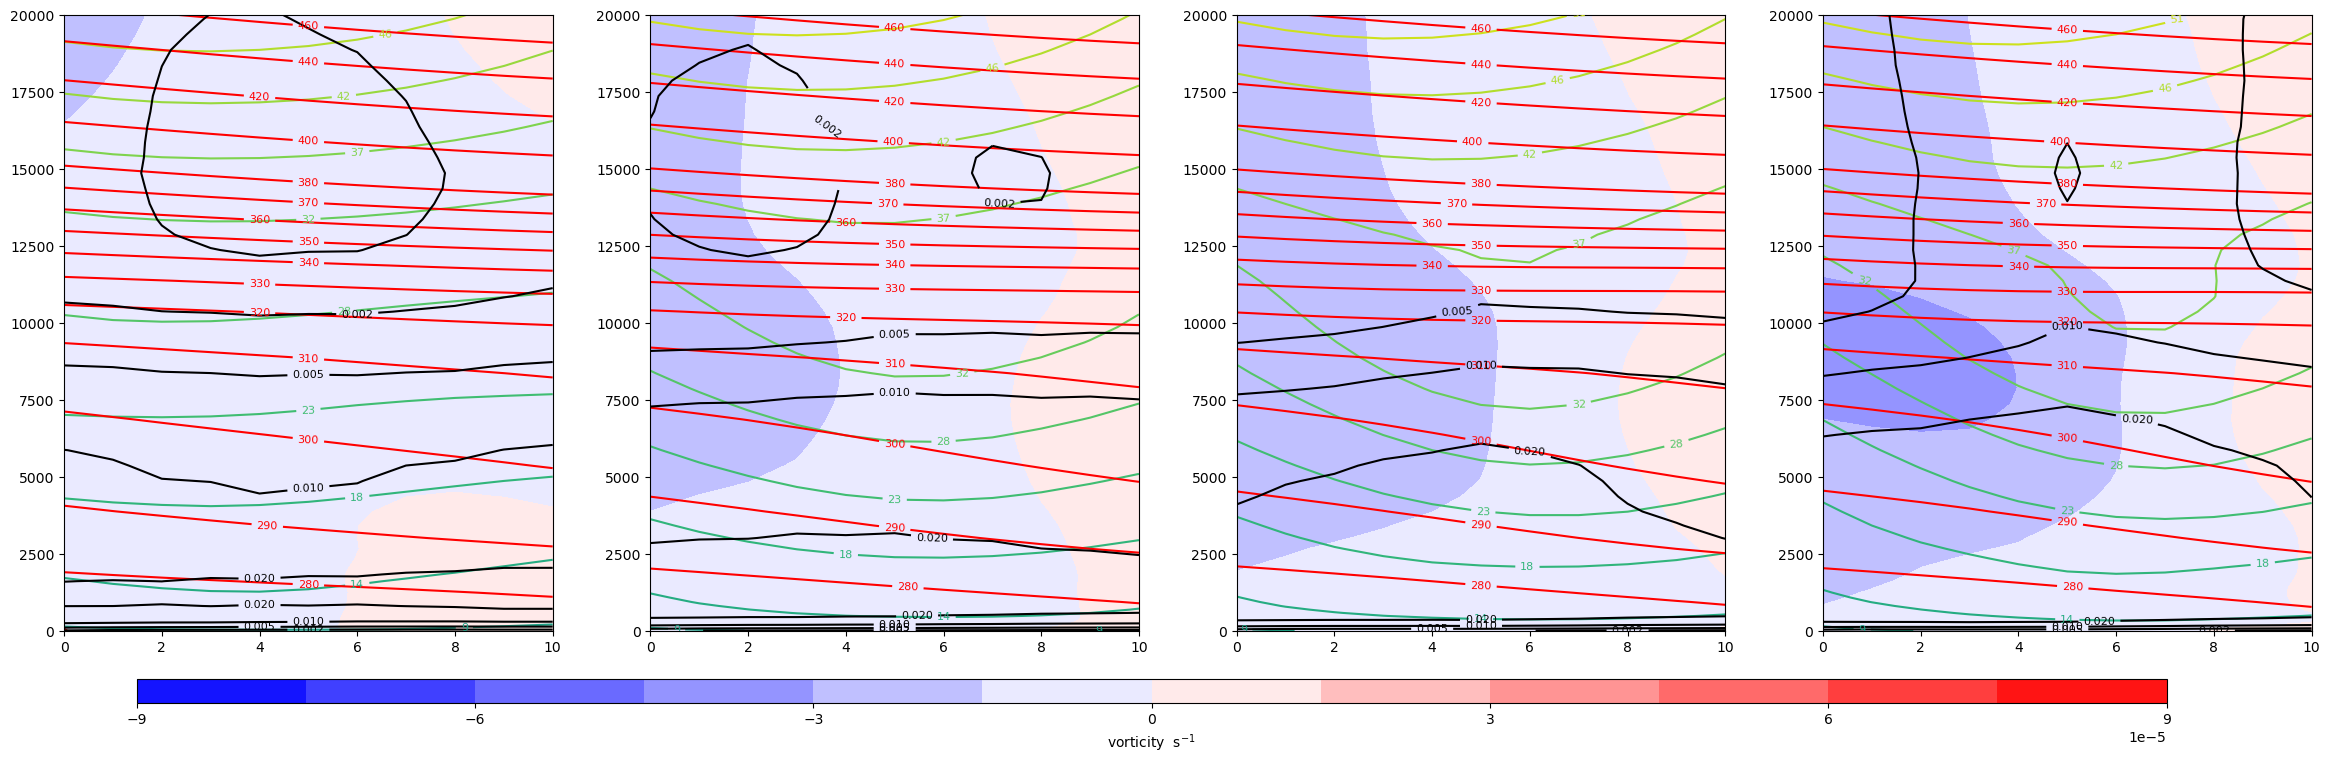

In [7]:
zetalv=1.5e-5*np.linspace(-6,6,num=13)
ulv=np.linspace(-60,60,num=27)
thlv=np.concatenate( (270.+np.arange(11)*10 , 380.+ np.arange(11)*20) )   #np.linspace(270,600,num=27)
mflv=[0.001,0.002,.005, .01, .02]
Epls=[El[0], El[1], El[2], El[3] ] #, Eco_0 ]
print(thlv)
nxplo,nyplo=len( Epls ),1
fig,axs=plt.subplots( nyplo,nxplo , figsize=(nxplo*7+1,nyplo*8) )
axs=axs.flatten()
p=0

for Epl in Epls:
    nv,nt_v,nz_v,ny_v,nx_v = np.shape( Epl.zeta_4D )
    delta_time=3

    ax=axs[p]
    Epl_vv=euti.avg_over_v(Epl)
    zeta_poo=Epl_vv.zeta_4D.mean(axis=3)
    u_poo=Epl_vv.u_4D.mean(axis=3)
    th_poo=Epl_vv.th_4D.mean(axis=3)
    epwp_poo=Epl_vv.epwp_4D.mean(axis=3)
    colo = ax.contourf( np.arange(ny_v), zlev, zeta_poo[nt_v-1,:,:], cmap='bwr' , levels=zetalv)
    lin1 = ax.contour( np.arange(ny_v), zlev, u_poo[nt_v-1,:,:] , levels=ulv)
    ax.clabel(lin1, inline=True, fontsize=8, fmt='%1.0f')
    lin2 = ax.contour( np.arange(ny_v), zlev, th_poo[nt_v-1,:,:] , levels=thlv, colors='red')
    ax.clabel(lin2, inline=True, fontsize=8, fmt='%1.0f')
    lin3 = ax.contour( np.arange(ny_v), zlev, epwp_poo[nt_v-1,:,:] , levels=mflv, colors='black')
    ax.clabel(lin3, inline=True, fontsize=8, fmt='%1.3f')
    ax.set_ylim(0,20_000)
    p=p+1

cax = fig.add_axes([0.15, 0.02, 0.70, 0.03])
cbar = fig.colorbar(colo, cax=cax, orientation='horizontal')
cbar.set_label(f"vorticity  s{r'$^{-1}$' }")
"""
cax = fig.add_axes([0.15, -0.1, 0.70, 0.03])
cbar = fig.colorbar(linc, cax=cax, orientation='horizontal')
cbar.set_label('Some quantity')
"""

[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
 Couldn't average ds over events
 Couldn't average ds over events
 Couldn't average ds over events
 Couldn't average ds over events


"\ncax = fig.add_axes([0.15, -0.1, 0.70, 0.03])\ncbar = fig.colorbar(linc, cax=cax, orientation='horizontal')\ncbar.set_label('Some quantity')\n"

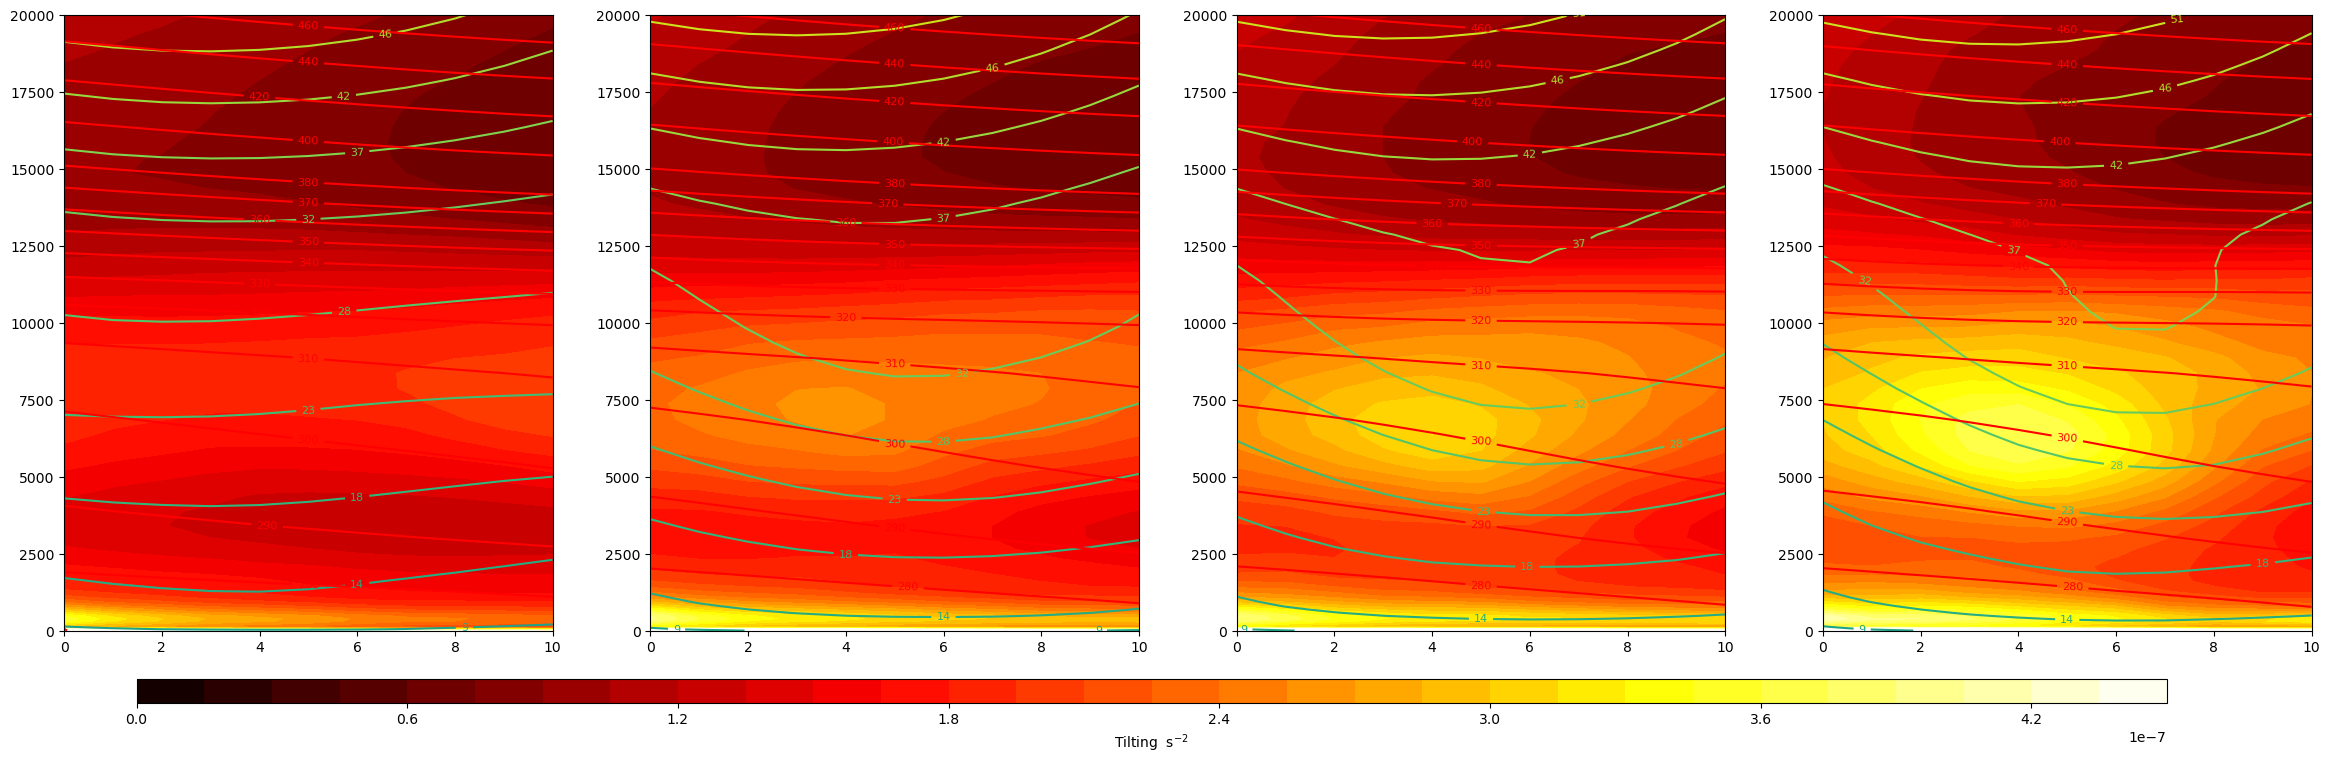

In [8]:
zetalv=0.75e-7*np.linspace(0,6,num=31)
ulv=np.linspace(-60,60,num=27)
thlv=np.concatenate( (270.+np.arange(11)*10 , 380.+ np.arange(11)*20) )   #np.linspace(270,600,num=27)
Epls=[El[0], El[1], El[2], El[3] ] #, Eco_0 ]
print(thlv)
nxplo,nyplo=len( Epls ),1
fig,axs=plt.subplots( nyplo,nxplo , figsize=(nxplo*7+1,nyplo*8) )
axs=axs.flatten()
p=0

for Epl in Epls:
    nv,nt_v,nz_v,ny_v,nx_v = np.shape( Epl.zeta_4D )
    delta_time=3

    ax=axs[p]
    Epl_vv=euti.avg_over_v(Epl)
    tilt_poo=Epl_vv.tilt_4D.mean(axis=3)
    u_poo=Epl_vv.u_4D.mean(axis=3)
    th_poo=Epl_vv.th_4D.mean(axis=3)
    colo = ax.contourf( np.arange(ny_v), zlev, tilt_poo[nt_v-1,:,:], cmap='hot' , levels=zetalv)
    lin1 = ax.contour( np.arange(ny_v), zlev, u_poo[nt_v-1,:,:] , levels=ulv)
    ax.clabel(lin1, inline=True, fontsize=8, fmt='%1.0f')
    lin2 = ax.contour( np.arange(ny_v), zlev, th_poo[nt_v-1,:,:] , levels=thlv, colors='red')
    ax.clabel(lin2, inline=True, fontsize=8, fmt='%1.0f')
    ax.set_ylim(0,20_000)
    p=p+1

cax = fig.add_axes([0.15, 0.02, 0.70, 0.03])
cbar = fig.colorbar(colo, cax=cax, orientation='horizontal')
cbar.set_label(f"Tilting  s{r'$^{-2}$' }")
"""
cax = fig.add_axes([0.15, -0.1, 0.70, 0.03])
cbar = fig.colorbar(linc, cax=cax, orientation='horizontal')
cbar.set_label('Some quantity')
"""

[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
 Couldn't average ds over events
 Couldn't average ds over events
 Couldn't average ds over events
 Couldn't average ds over events


"\ncax = fig.add_axes([0.15, -0.1, 0.70, 0.03])\ncbar = fig.colorbar(linc, cax=cax, orientation='horizontal')\ncbar.set_label('Some quantity')\n"

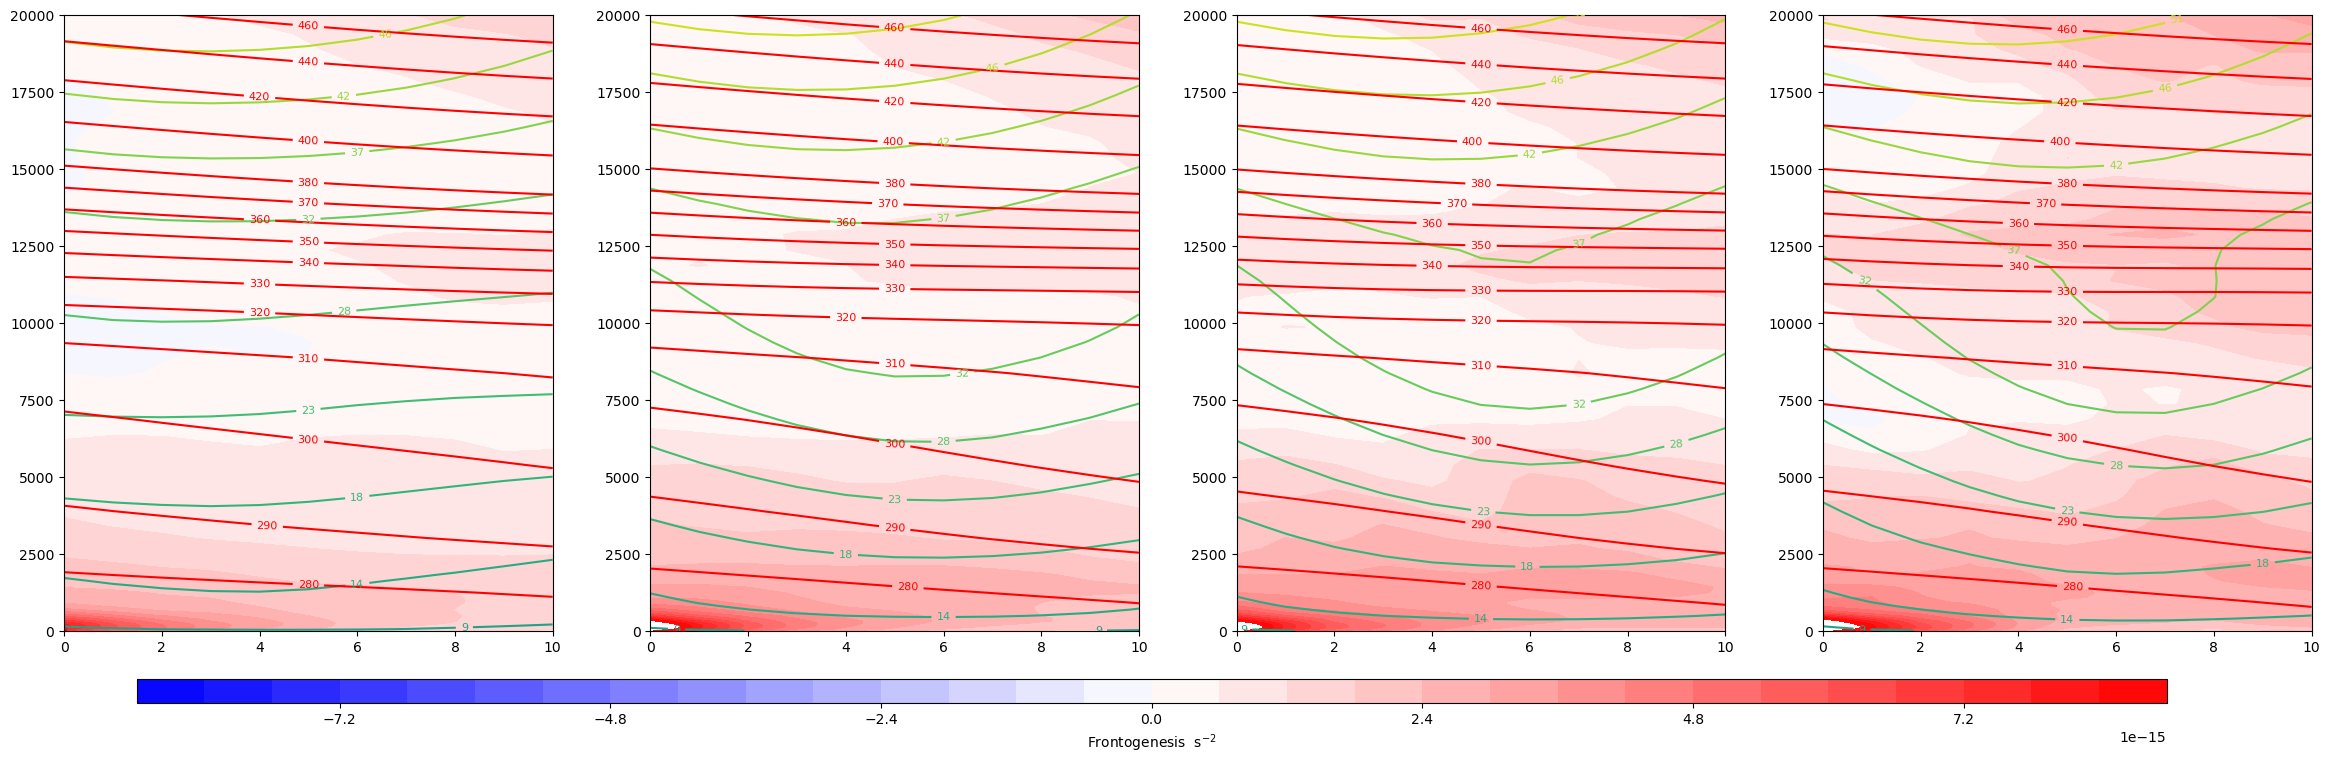

In [9]:
zetalv=1.5e-15*np.linspace(-6,6,num=31)
ulv=np.linspace(-60,60,num=27)
thlv=np.concatenate( (270.+np.arange(11)*10 , 380.+ np.arange(11)*20) )   #np.linspace(270,600,num=27)
Epls=[El[0], El[1], El[2], El[3] ] #, Eco_0 ]
print(thlv)
nxplo,nyplo=len( Epls ),1
fig,axs=plt.subplots( nyplo,nxplo , figsize=(nxplo*7+1,nyplo*8) )
axs=axs.flatten()
p=0

for Epl in Epls:
    nv,nt_v,nz_v,ny_v,nx_v = np.shape( Epl.zeta_4D )
    delta_time=3

    ax=axs[p]
    Epl_vv=euti.avg_over_v(Epl)
    tilt_poo=Epl_vv.fgf_4D.mean(axis=3)
    u_poo=Epl_vv.u_4D.mean(axis=3)
    th_poo=Epl_vv.th_4D.mean(axis=3)
    colo = ax.contourf( np.arange(ny_v), zlev, tilt_poo[nt_v-1,:,:], cmap='bwr' , levels=zetalv)
    lin1 = ax.contour( np.arange(ny_v), zlev, u_poo[nt_v-1,:,:] , levels=ulv)
    ax.clabel(lin1, inline=True, fontsize=8, fmt='%1.0f')
    lin2 = ax.contour( np.arange(ny_v), zlev, th_poo[nt_v-1,:,:] , levels=thlv, colors='red')
    ax.clabel(lin2, inline=True, fontsize=8, fmt='%1.0f')
    ax.set_ylim(0,20_000)
    p=p+1

cax = fig.add_axes([0.15, 0.02, 0.70, 0.03])
cbar = fig.colorbar(colo, cax=cax, orientation='horizontal')
cbar.set_label(f"Frontogenesis  s{r'$^{-2}$' }")
"""
cax = fig.add_axes([0.15, -0.1, 0.70, 0.03])
cbar = fig.colorbar(linc, cax=cax, orientation='horizontal')
cbar.set_label('Some quantity')
"""

In [ ]:
print(poopypants)

In [10]:

import random_forest as RF

In [11]:
Eco=euti.combine_event_dicts(El[3], El[1], label_key='event_strength')

Note: these keys were not concatenated (kept strong version): ['ds']
Combined: 1447 strong + 8160 weak = 9607 total events


(9607, 3, 93, 11, 11)
(9607,)
Patch mean zeta vs patch mean epwp: r=0.104, p=1.14e-24
Patch mean tilt vs patch mean epwp: r=0.503, p=0.00e+00
Patch mean fgf vs patch mean epwp: r=0.101, p=3.77e-23


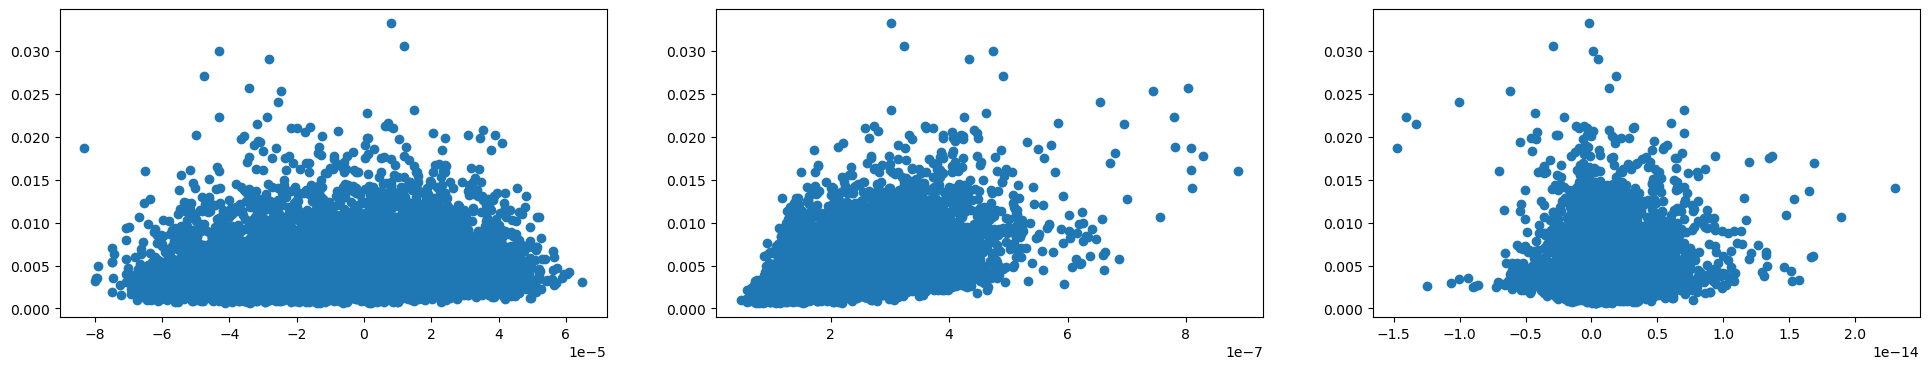

In [18]:
from scipy import stats

z0=np.argmin( np.abs( zlev-0.))
z3=np.argmin( np.abs( zlev-3000.))
z5=np.argmin( np.abs( zlev-5000.))
z6=np.argmin( np.abs( zlev-6000.))
z7=np.argmin( np.abs( zlev-7000.))
z10=np.argmin( np.abs( zlev-10000.))
z11=np.argmin( np.abs( zlev-11000.))
z12=np.argmin( np.abs( zlev-12000.))
z15=np.argmin( np.abs( zlev-15000.))
print(Eco.epwp_4D.shape)

#xv=Eco.zeta_4D[:,1,z6,4,:].mean(axis=1)
#xv=np.mean(Eco.zeta_4D[:,:,z10,4,:],axis=(1,2))
#xv=np.mean(Eco.zeta_4D[:,:,z7,:,:],axis=(1,2,3))
#xv=np.mean( Eco.tilt_4D[:,:,z7,:,:],axis=(1,2,3)  ) 

xvs=[]
xvs.append( np.mean( Eco.zeta_4D[:,:,z10:z3,:,:],axis=(1,2,3,4)  ) )
xvs.append( np.mean( Eco.tilt_4D[:,:,z10:z3,:,:],axis=(1,2,3,4)  ) )
xvs.append( np.mean( Eco.fgf_4D[:,:,z10:z3,:,:],axis=(1,2,3,4)  ) )
flds=['zeta','tilt','fgf']

yv=np.mean( Eco.epwp_4D[:,:,z10,:,:],axis=(3,2,1) )
#yv=np.mean( Eco.epwp_4D[:,nt_v-1,z10,:,:],axis=(2,1) )
print(yv.shape)

fig,axs=plt.subplots( 1, len(xvs), figsize=( (len(xvs)*8, 4 ) ) )
ip=0
for xv in xvs:
    ax=axs[ip]
    ax.scatter( xv,yv )
    r, p = stats.pearsonr(xv, yv)
    print(f"Patch mean {flds[ip]} vs patch mean epwp: r={r:.3f}, p={p:.2e}")
    ip=ip+1


Predictors = ['tilt_4D', 'zeta_4D']
predictor scaled by 1.0
target scaled by 1.0
Feature matrix: 9607 events x 36 predictors
Time-based split:
  Train: t=[48, 248)  → 7785 events
  Test:  t=[0,  28)   → 1117 events
Train R²:  0.541
Test  R²:  0.362
Test  r:   0.622  (p=1.12e-120)


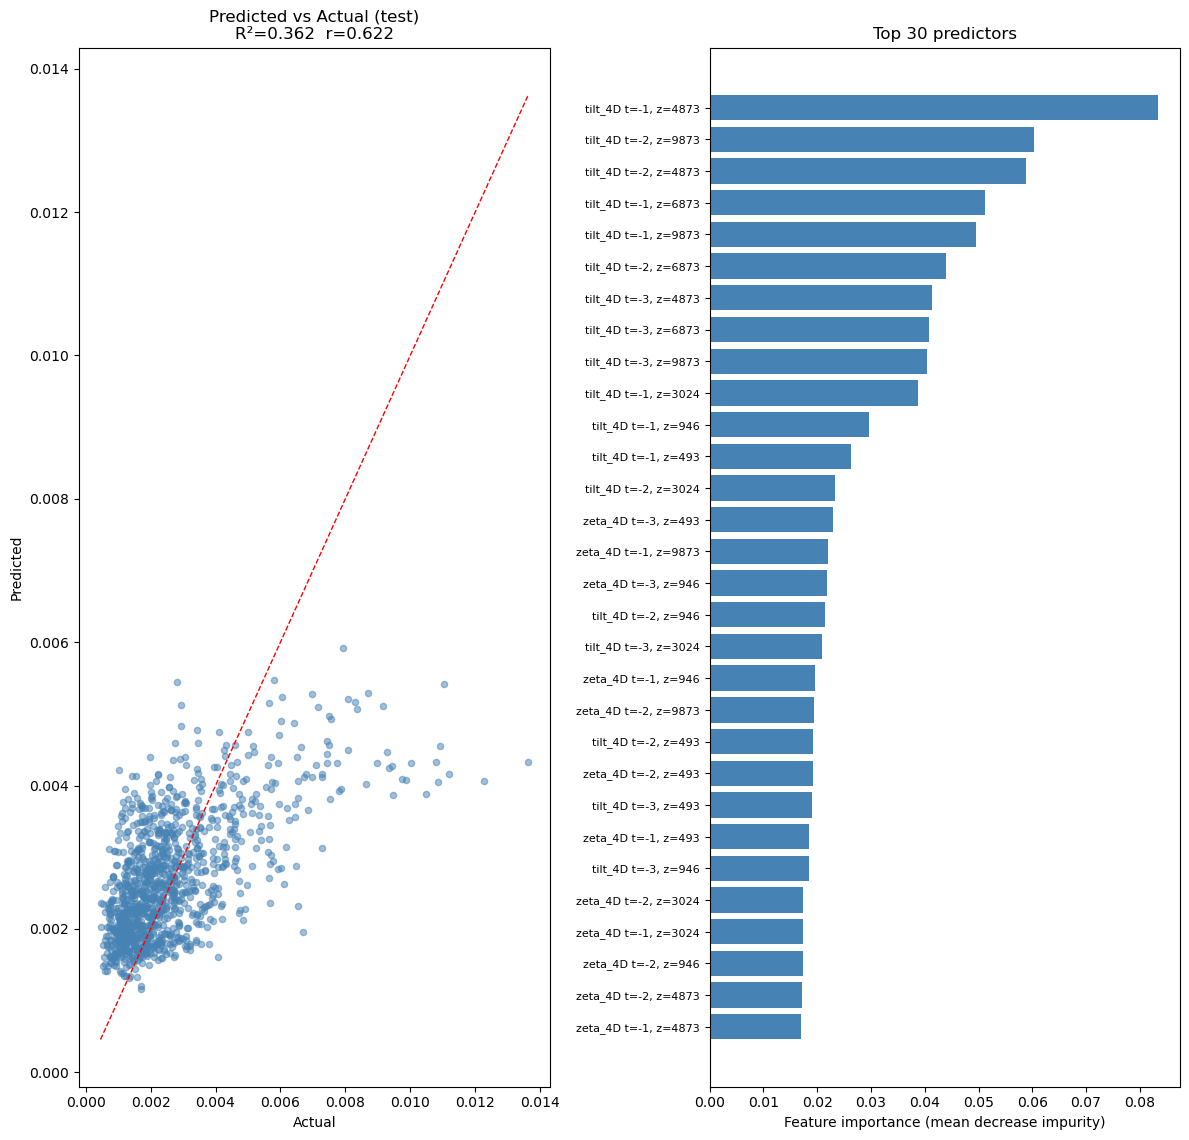

In [15]:
importlib.reload(RF)

"""
predictors= [ np.mean( Eco.tilt_4D[:,:,z10:znt_v-1,:,:],axis=(1,2,3,4)  ) , #vertavg 3 to 10km. time-space patch avg tilting 
              np.mean( Eco.zeta_4D[:,:,z10:znt_v-1,:,:],axis=(1,2,3,4)  ) , #vertavg 3 to 10km. time-space patch avg vorticity 
            ]
predictor_names= [  "vertavg 3 to 10km. time-space patch avg tilting", 
                    "vertavg 3 to 10km. time-space patch avg vorticity",
                ]
"""

z0=np.argmin( np.abs( zlev-0.))
z0p5=np.argmin( np.abs( zlev-500))
z1=np.argmin( np.abs( zlev-1000.))
z3=np.argmin( np.abs( zlev-3000.))
z5=np.argmin( np.abs( zlev-5000.))
z6=np.argmin( np.abs( zlev-6000.))
z7=np.argmin( np.abs( zlev-7000.))
z10=np.argmin( np.abs( zlev-10000.))
z11=np.argmin( np.abs( zlev-11000.))
z12=np.argmin( np.abs( zlev-12000.))
z15=np.argmin( np.abs( zlev-15000.))

predictors=[]
predictor_names=[]

pred_scaling=1.
targ_scaling=1.
use_predictors=['tilt_4D','zeta_4D']
#use_predictors=['tilt_4D',]
"""
for t in np.arange(4):
    for z in np.arange( start=z12, stop=z0 ):
        for prd in use_predictors:
            predictors.append( pred_scaling*np.mean( Eco[prd][:,t,z,0:6,:],axis=(1,2) ) )
            predictor_names.append( f"{prd} t={t-3}, z={zlev[z]}" )
            #predictors.append( np.mean( pred_scaling*Eco.tilt_4D[:,t,z,0:6,:],axis=(1,2) ) )
            #predictor_names.append( f"tilt t={t-3}, z={zlev[z]}" )
"""
#"""
key_z = [z0p5,z1,z3, z5, z7, z10]
for t in np.arange(nt_v):
    for z in key_z:
        for prd in use_predictors:
            predictors.append(np.mean(Eco[prd][:,t,z,0:6,:], axis=(1,2)))
            predictor_names.append(f"{prd} t={t-3}, z={zlev[z]:.0f}")
#"""
"""
key_z = [z5, z7, z10]# z10]
for z in key_z:
    predictors.append(np.mean(Eco.zeta_4D[:,:,z,0:6,:], axis=(1,2, 3)))
    predictor_names.append(f"vort time-avg, z={zlev[z]:.0f}")
    predictors.append(np.mean(Eco.tilt_4D[:,:,z,0:6,:], axis=(1,2, 3)))
    predictor_names.append(f"tilt time-avg, z={zlev[z]:.0f}")
"""

yv=targ_scaling*np.mean( Eco.epwp_4D[:,:,z12,:,:],axis=(3,2,1) )

print( f"Predictors = {use_predictors}" )
print(f"predictor scaled by {pred_scaling}")
print(f"target scaled by {targ_scaling}")

# fit
rf, results = RF.fit_rf_general(predictors=predictors, 
                                   predictor_names=predictor_names, 
                                   target=yv,
                                   event_times = Eco.time4D ,
                                   train_interval   = (48,248), #(0, 200),   # days 1-25
                                   test_interval    = (0,28), # (220,248),   # days 29-31, gap of 3 days
                                   min_samples_leaf=10,
                                    )

# plot
RF.plot_rf_results(results, top_n=30)



# optional permutation importance
#results = RF.add_permutation_importance(rf, results)

In [ ]:
Eco.time4D.shape
plt.plot( Eco.time4D )

In [ ]:
z6=np.argmin( np.abs( zlev-6000.))
z11=np.argmin( np.abs( zlev-11000.))
z15=np.argmin( np.abs( zlev-15000.))

z_sel=[20,30,40,50,56]
#z_sel=[28,50]
zlev_pred=zlev[z_sel]
zeta_pred=Eco.zeta_4D[:,:,z_sel,:,:]
fgf_pred=Eco.fgf_4D[:,:,z_sel,:,:]
tilt_pred=Eco.tilt_4D[:,:,z_sel,:,:]
precl_pred=Eco.precl_4D[:,:,z_sel,:,:]


In [ ]:
# build predictors
importlib.reload(RF)
X, feature_names = RF.build_predictor_matrix(
    #field_arrays = [zeta_pred, fgf_pred, tilt_pred],  #, precl_pred],
    field_arrays = [ zeta_pred ], #,tilt_pred],  #, precl_pred],
    #field_names  = ['vort', 'fgf', 'tilt', 'rain'],
    field_names  = ['vort'], #,'tilt'],
    zlev         = zlev_pred/1_000.,
    z_top_km     = 12.0,
    t_indices    = [-3, -2, -1],
    mode         = 'full',    # start simple, try 'full' later
)

# build target
y = RF.build_target(Eco.epwp_4D, zlev/1000., z_target_km=10.0)

# fit random forest
rf, splits, scores = RF.fit_random_forest(X, y)

# plot feature importance
#poo = RF.plot_feature_importance(rf, feature_names, top_n=30)

## A little exploration



## Begin clustering analysis



In [ ]:
import clustering as clst


# assemble
X, info = clst.assemble_feature_matrix(
    field_arrays=[El[3].zeta_4D, El[3].u_4D, El[3].v_4D, El[3].epwp_4D],
    field_names=['vort', 'u', 'v', 'mf_abs']
)

In [ ]:
X.shape

In [ ]:
import umap

In [ ]:
# PCA
X_pca, pca, scaler = clst.run_pca(X, n_components=50)
clst.plot_pca_variance(pca)

In [ ]:
X_pca.shape

In [ ]:
# clustering

labels, Z = clst.run_clustering(X_pca, n_clusters=3, method='both')
clst.plot_dendrogram(Z, n_events=X.shape[0])
clst.plot_pca_scatter(X_pca, labels, label_key='kmeans')

In [ ]:
importlib.reload(clst)
# vorticity at ~7km
z_idx_vort = np.argmin(np.abs(zlev - 10_000.0))   # finds nearest level to 7km

fig, axes, comp_vort = clst.plot_cluster_composites(
    field_4D      = El[3].zeta_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'Vorticity',
    zlev          = zlev,
    z_idx         = z_idx_vort,
    suptitle      = 'Vorticity composites by cluster',
)

# u-wind at ~17km
z_idx_u = np.argmin(np.abs(zlev - 10_000.0))

fig, axes, comp_u = clst.plot_cluster_composites(
    field_4D      = El[3].u_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'U wind',
    zlev          = zlev,
    z_idx         = z_idx_u,
    suptitle      = 'U-wind composites by cluster',
)

# u-wind at ~17km
z_idx_v = np.argmin(np.abs(zlev - 10_000.0))

fig, axes, comp_u = clst.plot_cluster_composites(
    field_4D      = El[3].v_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'U wind',
    zlev          = zlev,
    z_idx         = z_idx_u,
    suptitle      = 'U-wind composites by cluster',
)



In [ ]:
importlib.reload(clst)
# vorticity at ~7km
z_idx_vort = np.argmin(np.abs(zlev - 8_000.0))   # finds nearest level to 7km
# PC1 loading in vorticity space at 6km
ooo=clst.plot_pc_loading(pca, component_idx=0, feature_info=info,
                zlev=zlev, z_idx=z_idx_vort, field_idx=0)
ooo=clst.plot_pc_loading(pca, component_idx=1, feature_info=info,
                zlev=zlev, z_idx=z_idx_vort, field_idx=0)


In [ ]:
n_clusters =  np.max( labels['kmeans']  )+1
plt.plot( labels['kmeans'], '.' )


# dictionary of event indices for each cluster
cluster_indices = {k: np.where(labels['kmeans'] == k)[0] 
                   for k in range(n_clusters)}

# access like this
#idx_cluster0 = cluster_indices[0]  # array of event indices for cluster 0
#idx_cluster1 = cluster_indices[1]
# etc.

In [ ]:
print(len(El))

In [ ]:
El[0].keys()

In [ ]:
importlib.reload(euti)

In [ ]:
Eco=euti.combine_event_dicts(El[3], El[0], label_key='event_strength')

In [ ]:
Eco.zeta_4D.shape

In [ ]:
print(Eco.precl_4D.shape)

precip_tiled = np.tile(
    Eco.precl_4D[:, :, np.newaxis, :, :],  # add dummy z axis first
    (1, 1, nz, 1, 1)                                  # tile n_z times in z
)
print(precip_tiled.shape)


In [ ]:
import clustering as clst

"""
# assemble
X, info = clst.assemble_feature_matrix(
    field_arrays=[Eco.zeta_4D, Eco.u_4D, Eco.v_4D, Eco.epwp_4D],
    field_names=['vort', 'u', 'v', 'mf_abs']
)
"""
# assemble
z12=np.argmin( np.abs( zlev-12_000.) )
X, info = clst.assemble_feature_matrix(
    field_arrays=[ Eco.zeta_4D,  Eco.epwp_4D, precip_tiled ],
    field_names=['vort', 'mf_abs','precip']
)



In [ ]:
# PCA
X_pca, pca, scaler = clst.run_pca(X, n_components=50)
clst.plot_pca_variance(pca)

In [ ]:
# clustering

labels, Z = clst.run_clustering(X_pca, n_clusters=2, method='both')
clst.plot_dendrogram(Z, n_events=X.shape[0])
clst.plot_pca_scatter(X_pca, labels, label_key='kmeans')

In [ ]:
importlib.reload(clst)
# vorticity at ~7km
z_idx_vort = np.argmin(np.abs(zlev - 10_000.0))   # finds nearest level to 7km

fig, axes, comp_vort = clst.plot_cluster_composites(
    field_4D      = Eco.zeta_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'Vorticity',
    zlev          = zlev,
    z_idx         = z_idx_vort,
    suptitle      = 'Vorticity composites by cluster',
)
"""
# u-wind at ~17km
z_idx_u = np.argmin(np.abs(zlev - 10_000.0))

fig, axes, comp_u = clst.plot_cluster_composites(
    field_4D      = Eco.u_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'U wind',
    zlev          = zlev,
    z_idx         = z_idx_u,
    suptitle      = 'U-wind composites by cluster',
)

# u-wind at ~17km
z_idx_v = np.argmin(np.abs(zlev - 10_000.0))

fig, axes, comp_v = clst.plot_cluster_composites(
    field_4D      = Eco.v_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'V wind',
    zlev          = zlev,
    z_idx         = z_idx_v,
    suptitle      = 'U-wind composites by cluster',
)
"""
# u-wind at ~17km
z_idx_epwp = np.argmin(np.abs(zlev - 20_000.0))

fig, axes, comp_epwp = clst.plot_cluster_composites(
    field_4D      = Eco.epwp_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'AMF',
    zlev          = zlev,
    z_idx         = z_idx_epwp,
    suptitle      = 'Mom flux composites by cluster',
)

# u-wind at ~17km
z_idx_prec = np.argmin(np.abs(zlev - 10_000.0))

fig, axes, comp_epwp = clst.plot_cluster_composites(
    field_4D      = precip_tiled,
    cluster_labels = labels['kmeans'],
    field_name    = 'PRECL',
    zlev          = zlev,
    z_idx         = z_idx_prec,
    suptitle      = 'Precip composites by cluster',
)



In [ ]:
importlib.reload(clst)
# vorticity at ~7km
z_idx_vort = np.argmin(np.abs(zlev - 10_000.0))   # finds nearest level to 7km
# PC1 loading in vorticity space at 6km
ooo=clst.plot_pc_loading(pca, component_idx=0, feature_info=info,
                zlev=zlev, z_idx=z_idx_vort, field_idx=1)
ooo=clst.plot_pc_loading(pca, component_idx=1, feature_info=info,
                zlev=zlev, z_idx=z_idx_vort, field_idx=1)


In [ ]:
after_clusters='ooo'
print( after_clusters )

In [ ]:
# dictionary of event indices for each cluster
cluster_indices = {k: np.where(labels['kmeans'] == k)[0] 
                   for k in range(n_clusters)}

# access like this
idx_cluster0 = cluster_indices[0]  # array of event indices for cluster 0
idx_cluster1 = cluster_indices[1]
# etc.

In [ ]:
print(Eco.epwp_4D.shape)

In [ ]:
zlev_event=10_000. #23_000.
z_event= np.argmin( np.abs(zlev-zlev_event) )

In [ ]:
plt.plot(Eco.epwp_4D[:,3,z_event,5,5] )
plt.plot(Eco.epwp_4D[idx_cluster0,3,z_event,5,5] )


In [ ]:
Eco.keys()

Eco_0 = euti.subsample_event_dicts( Eco,idx_cluster0) 

In [ ]:
#Which list to plot
Epl = Eco_0  #El[3]

nv,nt_v,nz_v,ny_v,nx_v = np.shape( Epl.zeta_4D )
print( "NT V :", nt_v, nt_v//4 )
delta_time=3

nxplo=4
nyplo=nt_v//nxplo
    
z0=np.argmin( np.abs(zlev-zlev_event) )
z0=np.argmin( np.abs(zlev-10_000.) )
zS=np.argmin( np.abs(zlev-9_000.) )
zbot,ztop=   np.argmin( np.abs(zlev-5_000.) ) , np.argmin( np.abs(zlev-10_000.) )
zeta_zv =np.mean(Epl.zeta_4D[:,:,ztop:zbot+1,:,:],axis=2)

fig,axs=plt.subplots( nyplo,nxplo , figsize=(nxplo*7+1,nyplo*6) )
#axs[1,3].axis('off')
dlon=lon[1]-lon[0]
dlat=A.lat[3]-A.lat[2]
print( dlat,dlon )
lonco=np.linspace( -5*dlon, 5*dlon, num=11 )
latco=np.linspace( -5*dlat, 5*dlat, num=11 )
axs=axs.flatten()
clv=1.e-4 * np.linspace(-3,3,num=51)
mlv=2.e-2*np.linspace(-2,2,num=11)
for p in np.arange(nt_v):
    ax=axs[p] 
    t=p
    #co = ax.contour( El[3].zeta_4D[e,t,zS,:,:] , levels=clv, cmap='bwr' )
    co = ax.contourf( lonco,latco,np.mean( Epl.zeta_4D[:,t,zS,:,:],axis=0) , levels=clv, cmap='bwr' ,alpha=1.0)
    #co = ax.contourf( np.mean( zeta_zv[:,t,:,:] ,axis=0) , levels=clv, cmap='bwr' )
    li = ax.contour( lonco,latco,np.mean( Epl.epwp_4D[:,t,z0,:,:],axis=0) , levels=mlv, cmap='gray' )
    ax.set_title( f"$t_0$-{(nt_v-1-p)*delta_time} hrs ",fontsize=18)
    ax.set_xlabel( "degrees from event center" ,fontsize=18)
    ax.set_ylabel( "degrees from event center" ,fontsize=18)
#plt.colorbar(co)
#plt.colorbar( co )
    

In [ ]:
Epl.keys()

In [ ]:
importlib.reload(euti)
Epl=El[3]
Epl_vv=euti.avg_over_v(Epl)

In [ ]:
zetalv=1.e-5*np.linspace(-6,6,num=13)
ulv=np.linspace(-60,60,num=27)
thlv=np.concatenate( (270.+np.arange(11)*10 , 380.+ np.arange(11)*20) )   #np.linspace(270,600,num=27)
Epls=[El[0], El[3] ] #, Eco_0 ]
print(thlv)
nxplo,nyplo=len( Epls ),1
fig,axs=plt.subplots( nyplo,nxplo , figsize=(nxplo*7+1,nyplo*8) )
axs=axs.flatten()
p=0

for Epl in Epls:
    ax=axs[p]
    Epl_vv=euti.avg_over_v(Epl)
    zeta_poo=Epl_vv.zeta_4D.mean(axis=3)
    u_poo=Epl_vv.u_4D.mean(axis=3)
    th_poo=Epl_vv.th_4D.mean(axis=3)
    colo = ax.contourf( np.arange(ny_v), zlev, zeta_poo[nt_v-1,:,:], cmap='bwr' , levels=zetalv)
    lin1 = ax.contour( np.arange(ny_v), zlev, u_poo[nt_v-1,:,:] , levels=ulv)
    ax.clabel(lin1, inline=True, fontsize=8, fmt='%1.0f')
    lin2 = ax.contour( np.arange(ny_v), zlev, th_poo[nt_v-1,:,:] , levels=thlv, colors='red')
    ax.clabel(lin2, inline=True, fontsize=8, fmt='%1.0f')
    ax.set_ylim(0,20_000)
    p=p+1

cax = fig.add_axes([0.15, 0.02, 0.70, 0.03])
cbar = fig.colorbar(colo, cax=cax, orientation='horizontal')
cbar.set_label(f"vorticity  s{r'$^{-1}$' }")
"""
cax = fig.add_axes([0.15, -0.1, 0.70, 0.03])
cbar = fig.colorbar(linc, cax=cax, orientation='horizontal')
cbar.set_label('Some quantity')
"""

In [ ]:
print( poopypants)

In [ ]:
importlib.reload(auti)
hoo,xr =auti.one_dim_pdf( Soo[0][:,zbot].flatten() , nbin=30)

plt.plot(xr,hoo)
plt.xlabel('correlation')
plt.ylabel('Probablity')


In [ ]:
plt.contour( lon,lat,A.htopo )
plt.scatter( El[0].lon4D, El[0].lat4D, c=np.log10(El[0].epwp_4D[:,3,20,2,2]) , s=5 )
#plt.scatter( lon4D, lat4D, c=htopo_4D[:,3,2,2] , s=10 )


In [ ]:
z0,z1=np.argmin( np.abs(zlev-1_000.) ),np.argmin( np.abs(zlev-10_000.) )


plt.contourf( np.mean( np.mean( A.tilt[:,z1:z0+1,:,:], axis=1) , axis=0) , levels=51)
plt.colorbar()
#plt.plot( A.zeta[:,z0,:,:].flatten() )

In [ ]:
print( "STOP HERE poopypants" )
print( "STOP HERE",poopypants )


In [ ]:
importlib.reload(auti)
for E in El:
    zeta_4D = E.zeta_4D
    tilt_4D = E.tilt_4D
    epwp_4D = E.epwp_4D
    upwp_4D = E.upwp_4D
    fgf_4D = E.fgf_4D
    u_4D = E.u_4D
    v_4D = E.v_4D
    precl_4D = E.precl_4D

    E['zeta_MMM'], E['zeta_super_mean'], E['zeta_super_min'], E['zeta_super_max'] = \
        auti.collapseSpaceTime(zeta_4D)

    E['epwp_MMM'], E['epwp_super_mean'], E['epwp_super_min'], E['epwp_super_max'] = \
        auti.collapseSpaceTime(epwp_4D)

    E['upwp_MMM'], E['upwp_super_mean'], E['upwp_super_min'], E['upwp_super_max'] = \
        auti.collapseSpaceTime(upwp_4D)

    E['tilt_MMM'], E['tilt_super_mean'], E['tilt_super_min'], E['tilt_super_max'] = \
        auti.collapseSpaceTime(tilt_4D)

    E['fgf_MMM'], E['fgf_super_mean'], E['fgf_super_min'], E['fgf_super_max'] = \
        auti.collapseSpaceTime(fgf_4D)

    E['u_MMM'], E['u_super_mean'], E['u_super_min'], E['u_super_max'] = \
        auti.collapseSpaceTime(u_4D)

    E['v_MMM'], E['v_super_mean'], E['v_super_min'], E['v_super_max'] = \
        auti.collapseSpaceTime(v_4D)

    E['precl_MMM'], E['precl_super_mean'], E['precl_super_min'], E['precl_super_max'] = \
        auti.collapseSpaceTime(precl_4D, TZHkey='etyx'   )


In [ ]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(figsize=(5, 8))
ax.plot( El[0].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[1].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[2].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[3].tilt_super_max.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

In [ ]:
from matplotlib.ticker import MaxNLocator
fig, axs = plt.subplots(1,4,figsize=(21, 8))

ax=axs[0]
ax.plot( El[0].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].u_super_mean.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[1]
ax.plot( El[0].zeta_super_min.mean(axis=0) , A.zlev )
ax.plot( El[1].zeta_super_min.mean(axis=0) , A.zlev )
ax.plot( El[2].zeta_super_min.mean(axis=0) , A.zlev )
ax.plot( El[3].zeta_super_min.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[2]
ax.plot( El[0].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[1].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[2].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[3].tilt_super_max.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[3]
ax.plot( El[0].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[1].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[2].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[3].upwp_super_min.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))



In [ ]:
A.zeta.shape
clv=1.e-5*np.linspace( -3.,3., num=61 )
plt.contourf( lat, zlev, np.mean( np.mean( A.zeta, axis=3) , axis=0) , levels=clv, cmap='bwr' )

In [ ]:


zeta_t0x0= El[0].zeta_4D[:,6,:,2,2]
zeta_MMMt0= El[0].zeta_MMM[0][:,6,:]

In [ ]:
El[0].zeta_MMM[0].shape

In [ ]:
z0=np.argmin( np.abs(zlev-zlev_event) )
#z0=np.argmin( np.abs(zlev-20_000.) )
zS=np.argmin( np.abs(zlev-7_000.) )

fig,axs=plt.subplots( 2,4 , figsize=(4*5+1,2*5) )
axs=axs.flatten()
e=100
clv=1.e-4 * np.linspace(-3,3,num=51)
for p in np.arange(7):
    ax=axs[p] 
    t=p
    #co = ax.contourf( El[3].zeta_4D[e,t,zS,:,:] , levels=clv, cmap='bwr' )
    co = ax.contourf( np.mean( El[3].zeta_4D[:,t,zS,:,:],axis=0) , levels=clv, cmap='bwr' )

#plt.colorbar( co )
    

In [ ]:
from matplotlib.ticker import MaxNLocator
fig, axs = plt.subplots(1,4,figsize=(21, 8))

ax=axs[0]
ax.plot( El[0].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].u_super_mean.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[1]
ax.plot( El[0].zeta_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].zeta_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].zeta_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].zeta_super_mean.mean(axis=0) , A.zlev )

ax.plot( zeta_t0x0.mean(axis=0) , A.zlev, color='black' , linestyle=':' )
ax.plot( zeta_MMMt0.mean(axis=0) , A.zlev, color='black' , linestyle='--' )

ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[2]
ax.plot( El[0].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].tilt_super_mean.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[3]
ax.plot( El[0].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[1].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[2].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[3].upwp_super_min.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))



In [ ]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(figsize=(5, 8))
ax.plot( El[0].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].tilt_super_mean.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

In [ ]:
z0=np.argmin( np.abs(zlev-zlev_event) )
#z0=np.argmin( np.abs(zlev-20_000.) )
zS=np.argmin( np.abs(zlev-7_000.) )
#plt.plot( tilt_super_max[:,zS])
#plt.scatter( np.log10(tilt_super_max[:,zS] ), epwp_super_max[:,z0] )
plt.scatter( np.log10(El[0].tilt_super_max[:,zS] ), El[0].epwp_super_max[:,z0] )
plt.scatter( np.log10(El[3].tilt_super_max[:,zS] ), El[3].epwp_super_max[:,z0] )


In [ ]:
z0=np.argmin( np.abs(zlev-zlev_event) )
z0=np.argmin( np.abs(zlev-20_000.) )
zS=np.argmin( np.abs(zlev-5_000.) )
#plt.plot( tilt_super_max[:,zS])
#plt.scatter( np.log10(tilt_super_max[:,zS] ), epwp_super_max[:,z0] )
#plt.scatter( (El[3].upwp_super_min[:,zS] ), El[3].upwp_super_min[:,z0] )
#plt.scatter( (El[3].precl_super_max ), El[3].upwp_super_min[:,zS] )
plt.scatter( (El[3].epwp_super_max[:,z0] ), El[3].upwp_super_min[:,zS] )
#plt.scatter( (El[2].epwp_super_mean[:,zS] ), El[2].epwp_super_max[:,z0] )


In [ ]:
importlib.reload(auti)
xdata,ydata = np.log10(tilt_super_max[:,zS]) , epwp_super_max[:,z0]
#xdata,ydata = np.sqrt(tilt_super_max[:,zS]) , epwp_super_max[:,z0]
pdf2d,xcens,ycens = auti.two_dim_pdf(xdata,ydata,nxbin=50,nybin=50,logx=False,logy=False, density=True )


In [ ]:
plt.contourf( xcens,ycens, np.log10(pdf2d+.0000001).T )
plt.colorbar()

In [ ]:
if A.ncdata !='none' and process_ncdata==True :
    caseB = Path(A.ncdata).parents[2].name
    print( f"Getting 'Mother' run {caseB} " )
    B = futi.read_case( case=caseB, nsteps=nsteps ) # , nsteps = 31*8 )
    have_caseB = True
else:
    have_caseB = False
 


if have_caseB == True:
    epwp_4D_B, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=B.rho_epwp , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    epwp_MMM_B = auti.collapseSpace( epwp_4D_B )
    epwp_B_super_mean = epwp_MMM_B[0].mean( axis=1 )
    epwp_B_super_min = epwp_MMM_B[1].min( axis=1 )
    epwp_B_super_max = epwp_MMM_B[2].max( axis=1 )


In [ ]:
from matplotlib.ticker import MaxNLocator

n=50 #100
n=50 #20

#print( f"time = {time_ev[n]}, lat = {lat[int(iy_ev[n])]}, lon = {lon[int(ix_ev[n])]} " )
#epwp,vort,U,zl = epwp_4D[n,5,:,5,5],zeta_4D[n,4,:,4,6], u_4D[n,4,:,4,6], zlev
epwp,vort,U,zl , V = epwp_4D[n,3,:,2,2],zeta_4D[n,3,:,2,2], u_4D[n,3,:,2,2], A.zlev , v_4D[n,3,:,2,2]
fig, ax1 = plt.subplots(figsize=(5, 8))

# First variable: upwp
ax1.plot(epwp, zl, color='tab:blue', linewidth=2)
ax1.plot(epwp_super_max[n,:], zl, color='tab:blue', linewidth=1)

if have_caseB == True:
    ax1.plot(epwp_B_super_max[n,:], zl, color='tab:blue', linewidth=1,linestyle=':')

ax1.set_xlabel("upwp", color='tab:blue')
ax1.tick_params(axis='x', colors='tab:blue')
ax1.set_ylabel("z")
ax1.set_ylim(0,40_000.)

# Second variable: U
ax2 = ax1.twiny()
ax2.plot(U, zl, color='tab:orange', linewidth=2, linestyle='--')
ax2.set_xlabel("U", color='tab:orange')
ax2.tick_params(axis='x', colors='tab:orange')

# Third variable: vorticity
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
ax3.plot(vort, zl, color='tab:green', linewidth=2, linestyle=':')
alpha=.8
ax3.plot(  zeta_super_mean[n,:]  , zl, color='tab:green', linewidth=2, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_min[n,:]  , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_max[n,:]  , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)

ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0005,0.0002 )
ax3.xaxis.set_major_locator(MaxNLocator(4))
# Optional: if pressure or model level increases downward
# ax1.invert_yaxis()


# fourth variable: V
ax4 = ax1.twiny()
ax4.spines["top"].set_position(("axes", 1.22))   # move this x-axis upward
ax4.plot(V, zl, color='tab:red', linewidth=2, linestyle=':')
ax4.set_xlabel("V", color='tab:red')
ax4.tick_params(axis='x', colors='tab:red')

# Third variable: vorticity
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
ax3.plot(vort, zl, color='tab:green', linewidth=2, linestyle=':')
alpha=.8
ax3.plot(  zeta_super_mean[n,:]  , zl, color='tab:green', linewidth=2, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_min[n,:]  , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_max[n,:]  , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)

ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0005,0.0002 )
ax3.xaxis.set_major_locator(MaxNLocator(4))
# Optional: if pressure or model level increases downward
# ax1.invert_yaxis()


plt.tight_layout()


In [ ]:
zeta_super_max.shape

In [ ]:
tilt_super_mean_mean = tilt_super_mean.mean( axis=0 )
tilt_super_min_min = tilt_super_min.min( axis=0 )
tilt_super_min_mean = tilt_super_min.mean( axis=0 )
tilt_super_min_std = tilt_super_min.std( axis=0 )
tilt_super_max_max = tilt_super_max.max( axis=0 )
tilt_super_max_mean = tilt_super_max.mean( axis=0 )
tilt_super_max_std = tilt_super_max.std( axis=0 )

zeta_super_mean_mean = zeta_super_mean.mean( axis=0 )
zeta_super_mean_std = zeta_super_mean.std( axis=0 )

zeta_super_min_min = zeta_super_min.min( axis=0 )
zeta_super_min_mean = zeta_super_min.mean( axis=0 )
zeta_super_min_std = zeta_super_min.std( axis=0 )
zeta_super_max_max = zeta_super_max.max( axis=0 )
zeta_super_max_mean = zeta_super_max.mean( axis=0 )
zeta_super_max_std = zeta_super_max.std( axis=0 )


In [ ]:
fig, ax3 = plt.subplots(figsize=(5, 8))
zl=A.zlev
## Third variable: vorticity
#ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
#ax3.plot(zeta_4D, zl, color='tab:green', linewidth=2, linestyle=':')
alpha=.8
ax3.plot(  zeta_super_mean_mean  , zl, color='tab:green', linewidth=2, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_min_mean , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_min_mean - 1*zeta_super_min_std  , zl, color='tab:green', linewidth=1, linestyle=":", alpha=alpha)
ax3.plot(  zeta_super_min_mean + 1*zeta_super_min_std  , zl, color='tab:green', linewidth=1, linestyle=":", alpha=alpha)
ax3.plot(  zeta_super_max_mean , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)
ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0003,0.0002 )

ax4 = ax3.twiny()
ax4.spines["top"].set_position(("axes", 1.22))   # move this x-axis upward

ax4.plot(  tilt_super_mean_mean  , zl, color='tab:red', linewidth=2, linestyle='-', alpha=alpha)
ax4.plot(  tilt_super_min_mean , zl, color='tab:red', linewidth=1, linestyle='-', alpha=alpha)
ax4.plot(  tilt_super_min_mean - 1*zeta_super_min_std  , zl, color='tab:red', linewidth=1, linestyle=":", alpha=alpha)
ax4.plot(  tilt_super_min_mean + 1*zeta_super_min_std  , zl, color='tab:red', linewidth=1, linestyle=":", alpha=alpha)
ax4.plot(  tilt_super_max_mean , zl, color='tab:red', linewidth=1, linestyle='-', alpha=alpha)


ax4.set_xlabel("Tilting Mag", color='tab:red')
ax4.tick_params(axis='x', colors='tab:red')




In [ ]:
nt,nz,ny,nx = np.shape( A.rho_epwp )
masktopo=A.htopo <  0.01
masktopo3D = np.tile(masktopo[None, :, :], ( nz, 1, 1))

In [ ]:
flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]


flev=0.1*np.asarray( flev )
print(flev)
flev2 = np.concatenate( [ -np.flip(flev) , flev ] )


cmapN='gist_ncar'

cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
cmap = plt.cm.gist_ncar # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)
norm2 = mcolors.BoundaryNorm(boundaries=flev2, ncolors=cmap.N, clip=False)

fig,axs = plt.subplots( 1, 2, figsize=(16,8) )


p=0
ax=axs[p]
ax.contourf( A.lat,A.zlev, np.mean( np.mean(A.rho_epwp[:,:,:,:], axis=0 ), axis=2 ) , levels=flev, cmap=cmap , norm=norm, extend='both' )
#plt.contourf( A.lat,A.zlev, np.mean( np.mean(A.rho_upwp, axis=0 ), axis=2 ) , levels=flev2, cmap=cmap , norm=norm2, extend='both' )
ax.set_ylim( 0. , 40_000. )

p=1
ax=axs[p]
ax.contourf( A.lat,A.zlev, np.mean( np.mean(B.rho_epwp[:,:,:,:], axis=0 )*masktopo3D , axis=2 ) / (np.mean( masktopo3D, axis=2) + 0.1) , levels=flev, cmap=cmap , norm=norm, extend='both' )
ax.contour( A.lat,A.zlev, np.mean( np.mean(B.u[:,:,:,:], axis=0 )*masktopo3D , axis=2 ) / (np.mean( masktopo3D, axis=2) + 0.1) , levels=21, colors='black')
ax.contour( A.lat,A.zlev, np.mean( np.mean(B.zeta[:,:,:,:], axis=0 )*masktopo3D , axis=2 ) / (np.mean( masktopo3D, axis=2) + 0.1) , levels=11, colors='gray')

#plt.contourf( A.lat,A.zlev, np.mean( np.mean(A.rho_upwp, axis=0 ), axis=2 ) , levels=flev2, cmap=cmap , norm=norm2, extend='both' )
ax.set_ylim( 0. , 40_000. )




In [ ]:
print( np.concatenate( [ -np.flip(flev) , flev ] ) )